# vidgrep OCR analysis

This notebook reuses vidgrep's OCR scan pipeline (`TextDetector` + `VideoClipper.scan_for_matches`)
on a single video, then turns the raw matches into labelled, human-readable tables and charts:

1. **Scan** — sample frames with FFmpeg, crop to a region, run EasyOCR, keep frames whose text
   matches a regex.
2. **Label** — build a DataFrame with readable timestamps, normalized text variants, and
   confidence bands.
3. **Visualize** — detection timeline, confidence distribution, text-variant counts, and a
   gallery of the actual matched frames.

Run it from `notebooks/` (the default when opening `ocr_analysis.ipynb` here) or the repo
root — the configuration cell finds the repo root either way. Adjust the configuration cell
to point at any other video/pattern.

In [ ]:
import json
import subprocess
import sys
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "vidgrep" / "detector.py").exists():
    REPO_ROOT = REPO_ROOT.parent  # notebook lives in notebooks/, repo root is one up
assert (REPO_ROOT / "vidgrep" / "detector.py").exists(), (
    "Run this notebook from notebooks/ or the repo root so the vidgrep package is importable."
)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from vidgrep.clipper import VideoClipper
from vidgrep.detector import TextDetector

# --- scan configuration ---------------------------------------------------
VIDEO_PATH   = REPO_ROOT / "scrap" / "smoke.mp4"
PATTERN      = "uwdivad"                # regex, case-insensitive (matches the killfeed gamertag)
REGION       = (132, 476, 592, 388)     # x, y, w, h crop around the killfeed
INTERVAL_SEC = 1.0                      # sample one frame per second
THRESHOLD    = 0.5                      # minimum OCR confidence
USE_GPU      = True
MERGE_GAP    = 2.0                      # seconds between matches before an interval splits
FORCE_RESCAN = False                    # set True to ignore the cache below
CACHE_PATH   = REPO_ROOT / "scrap" / "smoke_ocr_cache.json"

VIDEO_PATH

In [2]:
# Chart chrome: reference dataviz palette (light surface).
C = {
    "surface": "#fcfcfb", "ink": "#0b0b0b", "secondary": "#52514e",
    "muted": "#898781", "grid": "#e1e0d9", "baseline": "#c3c2b7",
    "blue": "#2a78d6", "blue_deep": "#184f95",
    "blue_soft": "#86b6ef", "blue_faint": "#cde2fb",
}
plt.rcParams.update({
    "figure.facecolor": C["surface"], "axes.facecolor": C["surface"],
    "savefig.facecolor": C["surface"],
    "axes.edgecolor": C["baseline"], "axes.labelcolor": C["secondary"],
    "axes.titlecolor": C["ink"], "axes.titlelocation": "left",
    "xtick.color": C["muted"], "ytick.color": C["muted"],
    "text.color": C["ink"], "font.family": "sans-serif",
    "axes.grid": True, "grid.color": C["grid"], "grid.linewidth": 0.8,
    "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.dpi": 110,
})

def mmss(seconds, _pos=None):
    seconds = int(seconds)
    return f"{seconds // 60}:{seconds % 60:02d}"

## Video metadata

Open the video with `VideoClipper` (the same probe the CLI uses) and derive the sampling stride
from the requested interval.

In [3]:
clipper = VideoClipper(str(VIDEO_PATH))
skip_frames = max(1, round(INTERVAL_SEC * clipper.fps))

pd.DataFrame(
    {
        "value": [
            VIDEO_PATH.name,
            f"{clipper._w} x {clipper._h}",
            f"{clipper.fps:.2f}",
            f"{clipper.duration:.1f} s ({mmss(clipper.duration)})",
            f"{clipper.frame_count:,}",
            f"every {skip_frames} frames (~{INTERVAL_SEC:g}s)",
            f"~{clipper.frame_count // skip_frames + 1}",
        ]
    },
    index=["file", "resolution", "fps", "duration", "frames", "sampling", "frames to OCR"],
)

Video: 2560x1440 @ 144.00 fps  |  26.6s  |  3,837 frames


,value
file,smoke.mp4
resolution,2560 x 1440
fps,144.00
duration,26.6 s (0:26)
frames,"3,837"
sampling,every 144 frames (~1s)
frames to OCR,~27


## Run the OCR scan

This is the same code path as `vidgrep scan`: frames are sampled and cropped inside FFmpeg
(`_FFSampler`), batched through EasyOCR, and each regex hit becomes a
`{"timestamp", "text", "confidence"}` record.

Results are cached to JSON so re-running the notebook doesn't redo OCR — flip `FORCE_RESCAN`
or change the configuration to rescan (the cache is keyed to the scan options).

In [4]:
def scan_options() -> dict:
    return {
        "video": str(VIDEO_PATH.resolve()), "pattern": PATTERN,
        "region": list(REGION), "interval": INTERVAL_SEC, "threshold": THRESHOLD,
    }

matches = None
if CACHE_PATH.exists() and not FORCE_RESCAN:
    cached = json.loads(CACHE_PATH.read_text(encoding="utf-8"))
    if cached.get("options") == scan_options():
        matches = cached["matches"]
        print(f"Loaded {len(matches)} cached matches from {CACHE_PATH.name}")

if matches is None:
    detector = TextDetector(PATTERN, gpu=USE_GPU, threshold=THRESHOLD)
    matches = clipper.scan_for_matches(
        detector, skip_frames=skip_frames, region=REGION, batch_size=8,
    )
    CACHE_PATH.write_text(
        json.dumps({"options": scan_options(), "matches": matches}, indent=2),
        encoding="utf-8",
    )
    print(f"Found {len(matches)} matches; cached to {CACHE_PATH.name}")

Loaded 14 cached matches from smoke_ocr_cache.json


## Label the raw matches

Turn the raw records into a human-readable table:

- **`time`** — `m:ss` wall-clock position instead of float seconds.
- **`text_normalized`** — lowercased, punctuation-stripped OCR text, so near-identical OCR
  readings (`Uwdivad`/`uwdivad`, `[PAKI…`/`[PAKJ…`) group together.
- **`confidence_band`** — high / medium / low labels for quick filtering.

In [5]:
df = pd.DataFrame(matches)
if df.empty:
    raise SystemExit("No matches found — adjust PATTERN/REGION/THRESHOLD and rescan.")

def confidence_band(c: float) -> str:
    if c >= 0.80:
        return "high (>= 0.80)"
    if c >= 0.60:
        return "medium (0.60-0.79)"
    return "low (< 0.60)"

df["time"] = df["timestamp"].map(mmss)
df["confidence_band"] = df["confidence"].map(confidence_band)
df["text_normalized"] = (
    df["text"].str.lower().str.replace(r"[^a-z0-9\[\] ]", "", regex=True).str.strip()
)

print(f"{len(df)} matches, {df['text_normalized'].nunique()} distinct text variants")
df[["time", "text", "confidence", "confidence_band", "text_normalized"]]

14 matches, 10 distinct text variants


,time,text,confidence,confidence_band,text_normalized
0,0:04,uwdivad kako4pabloiii1,0.9958,high (>= 0.80),uwdivad kako4pabloiii1
1,0:05,uwdivad kakko4pabloiii1,0.9987,high (>= 0.80),uwdivad kakko4pabloiii1
2,0:07,uwdivad kako4pabloiiil,0.9995,high (>= 0.80),uwdivad kako4pabloiiil
3,0:08,uwdivad T7 kako4pabloiii1,0.9675,high (>= 0.80),uwdivad t7 kako4pabloiii1
4,0:09,uwdivad kako4pabioiii1,0.9998,high (>= 0.80),uwdivad kako4pabioiii1
5,0:10,uwdivad kakoApabloiil |,0.9990,high (>= 0.80),uwdivad kakoapabloiil
6,0:13,uwdivad [PAKJBOUNDMASTER,0.9999,high (>= 0.80),uwdivad [pakjboundmaster
7,0:18,uwdivad [PAKJBOUNDMASTER,0.6708,medium (0.60-0.79),uwdivad [pakjboundmaster
8,0:19,uwdivad [PAKIBOUNDMASTER,0.9974,high (>= 0.80),uwdivad [pakiboundmaster
9,0:20,uwdivad [PAKIBOUNDMASTER,0.8594,high (>= 0.80),uwdivad [pakiboundmaster


## Match intervals

Merge consecutive detections into on-screen intervals, the same way `find_intervals` does for
clip extraction: matches closer than `MERGE_GAP` seconds belong to the same appearance.

In [6]:
intervals: list[list[float]] = []
for t in sorted(df["timestamp"].unique()):
    if intervals and t - intervals[-1][1] <= MERGE_GAP:
        intervals[-1][1] = t
    else:
        intervals.append([t, t])

pd.DataFrame(
    [
        {
            "interval": i,
            "start": mmss(s), "end": mmss(e),
            "duration_sec": round(e - s + INTERVAL_SEC, 1),
            "matches": int(((df["timestamp"] >= s) & (df["timestamp"] <= e)).sum()),
            "peak_confidence": df.loc[
                (df["timestamp"] >= s) & (df["timestamp"] <= e), "confidence"
            ].max(),
        }
        for i, (s, e) in enumerate(intervals, 1)
    ]
).set_index("interval")

,start,end,duration_sec,matches,peak_confidence
interval,,,,,
1,0:04,0:10,7.0,6,0.9998
2,0:13,0:13,1.0,1,0.9999
3,0:18,0:24,7.0,7,0.9974


## Detection timeline

Every OCR match plotted at its timestamp and confidence. Shaded bands are the merged
on-screen intervals — the spans `vidgrep` would cut clips around.

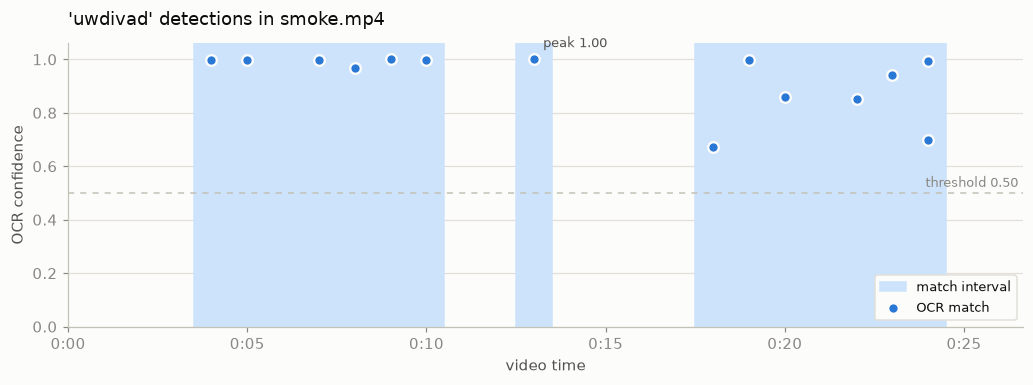

In [7]:
fig, ax = plt.subplots(figsize=(9.5, 3.6))

for i, (s, e) in enumerate(intervals):
    ax.axvspan(
        s - INTERVAL_SEC / 2, e + INTERVAL_SEC / 2,
        color=C["blue_faint"], zorder=1,
        label="match interval" if i == 0 else None,
    )

ax.scatter(
    df["timestamp"], df["confidence"], s=48,
    color=C["blue"], edgecolors=C["surface"], linewidths=1.5,
    zorder=3, label="OCR match",
)

ax.axhline(THRESHOLD, color=C["baseline"], linestyle=(0, (4, 4)), linewidth=1, zorder=2)
ax.annotate(
    f"threshold {THRESHOLD:.2f}", xy=(0.995, THRESHOLD),
    xycoords=("axes fraction", "data"), xytext=(0, 4), textcoords="offset points",
    ha="right", fontsize=8.5, color=C["muted"],
)

best = df.loc[df["confidence"].idxmax()]
ax.annotate(
    f"peak {best['confidence']:.2f}", xy=(best["timestamp"], best["confidence"]),
    xytext=(6, 8), textcoords="offset points", fontsize=8.5, color=C["secondary"],
)

ax.set_xlim(0, clipper.duration)
ax.set_ylim(0, 1.06)
ax.set_yticks(np.arange(0, 1.01, 0.2))
ax.xaxis.set_major_formatter(mticker.FuncFormatter(mmss))
ax.set_xlabel("video time")
ax.set_ylabel("OCR confidence")
ax.set_title(f"'{PATTERN}' detections in {VIDEO_PATH.name}", pad=12)
ax.grid(axis="x", visible=False)
legend = ax.legend(loc="lower right", fontsize=8.5, framealpha=1,
                   facecolor=C["surface"], edgecolor=C["grid"])
plt.tight_layout()
plt.show()

## Confidence distribution

How sure was the OCR about each match? A long low-confidence tail usually means the pattern is
picking up garbled killfeed lines and `THRESHOLD` could be raised.

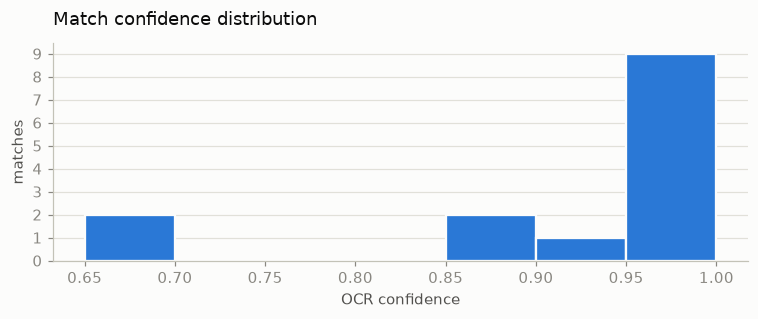

,matches
band,
high (>= 0.80),12
medium (0.60-0.79),2


In [8]:
fig, ax = plt.subplots(figsize=(7, 3))

lo = np.floor(df["confidence"].min() * 20) / 20
bins = np.arange(lo, 1.0001, 0.05)
ax.hist(df["confidence"], bins=bins, color=C["blue"], edgecolor=C["surface"], linewidth=1.5)

ax.set_xlabel("OCR confidence")
ax.set_ylabel("matches")
ax.set_title("Match confidence distribution", pad=12)
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

df["confidence_band"].value_counts().rename_axis("band").to_frame("matches")

## What did the OCR actually read?

Counts of the normalized text variants. One dominant variant with a few noisy misreads is
healthy; many fragmented variants suggest the region crop is clipping the text.

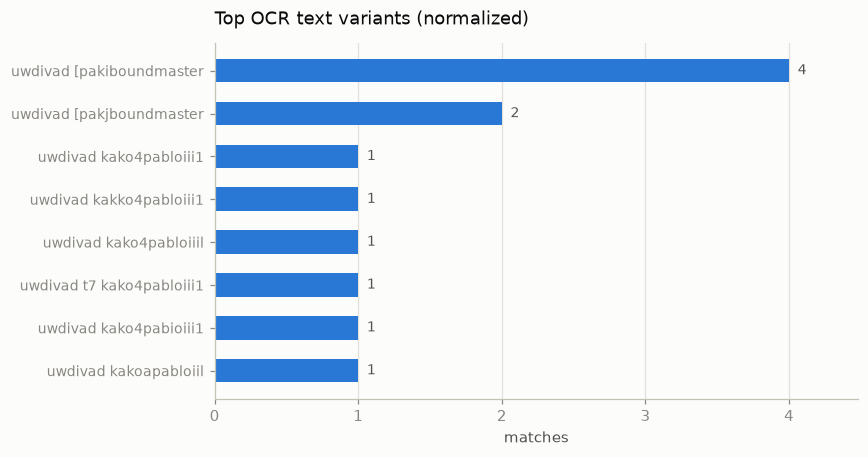

In [9]:
counts = df["text_normalized"].value_counts().head(8).iloc[::-1]

fig, ax = plt.subplots(figsize=(8, 0.9 + 0.42 * len(counts)))
ax.barh(counts.index, counts.values, color=C["blue"], height=0.55)
for y, value in enumerate(counts.values):
    ax.text(value + max(counts.values) * 0.015, y, str(value),
            va="center", fontsize=9, color=C["secondary"])

ax.set_xlabel("matches")
ax.set_title("Top OCR text variants (normalized)", pad=12)
ax.set_xlim(0, max(counts.values) * 1.12)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.grid(axis="y", visible=False)
ax.tick_params(axis="y", labelsize=9)
plt.tight_layout()
plt.show()

## Matched frames

The strongest match from each interval, with the scanned region outlined — a visual sanity
check that the OCR is reading what you think it is.

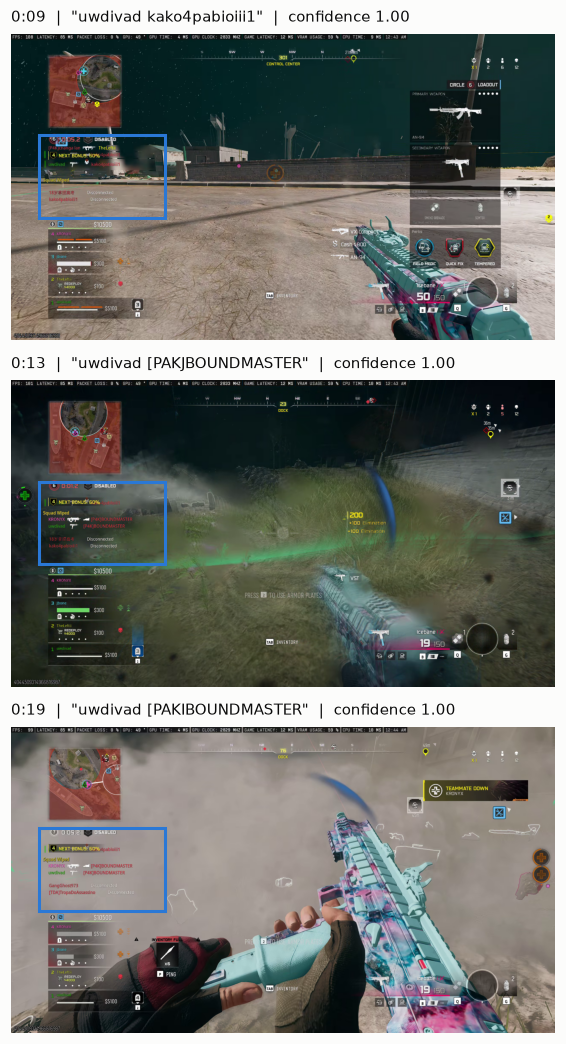

In [10]:
def grab_frame(seconds: float) -> np.ndarray:
    """Decode a single full frame at `seconds` via FFmpeg (handles AV1 and friends)."""
    out = subprocess.run(
        ["ffmpeg", "-ss", f"{seconds:.3f}", "-i", str(VIDEO_PATH), "-frames:v", "1",
         "-f", "image2pipe", "-vcodec", "png", "-loglevel", "error", "pipe:1"],
        capture_output=True, check=True,
    ).stdout
    frame = cv2.imdecode(np.frombuffer(out, np.uint8), cv2.IMREAD_COLOR)
    if frame is None:
        raise RuntimeError(f"Could not decode a frame at {seconds:.3f}s")
    return cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

picks = []
for s, e in intervals:
    rows = df[(df["timestamp"] >= s) & (df["timestamp"] <= e)]
    picks.append(rows.loc[rows["confidence"].idxmax()])
picks = picks[:4]

fig, axes = plt.subplots(len(picks), 1, figsize=(9.5, 3.2 * len(picks)), squeeze=False)
x, y, w, h = REGION
for ax, row in zip(axes.ravel(), picks):
    ax.imshow(grab_frame(row["timestamp"]))
    ax.add_patch(mpatches.Rectangle((x, y), w, h, fill=False,
                                    edgecolor=C["blue"], linewidth=2))
    ax.set_title(
        f"{row['time']}  |  \"{row['text']}\"  |  confidence {row['confidence']:.2f}",
        fontsize=10, pad=8,
    )
    ax.axis("off")
plt.tight_layout()
plt.show()

## Summary

In [11]:
coverage_sec = sum(e - s + INTERVAL_SEC for s, e in intervals)

pd.DataFrame(
    {
        "value": [
            PATTERN,
            len(df),
            df["text_normalized"].nunique(),
            len(intervals),
            f"{coverage_sec:.1f} s ({coverage_sec / clipper.duration:.0%} of video)",
            f"{df['confidence'].mean():.2f}",
            f"{df['confidence'].max():.2f} at {df.loc[df['confidence'].idxmax(), 'time']}",
            f"{df.loc[df['timestamp'].idxmin(), 'time']} - {df.loc[df['timestamp'].idxmax(), 'time']}",
        ]
    },
    index=[
        "pattern", "matches", "text variants", "on-screen intervals",
        "on-screen time", "mean confidence", "peak confidence", "first - last seen",
    ],
)

,value
pattern,uwdivad
matches,14
text variants,10
on-screen intervals,3
on-screen time,15.0 s (56% of video)
mean confidence,0.93
peak confidence,1.00 at 0:13
first - last seen,0:04 - 0:24
